
# Download images for processing
Like many major libraries and cultural heritage institutions, the British Library shares their collections using the International Image Interoperability Framework (IIIF) standard. IIIF provides a consistent way to request images and metadata.

At the same time, we recognize that researchers often work with a variety of materials from multiple institutions. Often, we work with photographs from the archives, personal collections, or other sources that may not be available through IIIF endpoints.

Whether you're working from an online collection or local files, we recommending that you first download all of the images that you want to process to a local folder. This approach has several advantages:

1. **Error Handling**: By downloading images first, you can handle any errors or issues with specific files before starting the processing workflow. Many library servers will limit the number of requests you can make in a given time period, which can interrupt your processing if you're fetching images on-the-fly.
2. **Reproducibility**: Having a local copy of the images ensures that your processing workflow can be reproduced later, even if the original online resources change or become unavailable.

In [ ]:
#  Mengo Hospital medical notes-1902 (EAP617)

manifest_url = "https://eap.bl.uk/archive-file/EAP617-1-10/manifest?manifest=https%3A//eap.bl.uk/archive-file/EAP617-1-10/manifest"

In [ ]:
# @title Install [IIIF-Download](https://github.com/Segolene-Albouy/iiif-download)

%pip install -q iiif-download

In [ ]:
# needed to run async in Jupyter

import nest_asyncio
nest_asyncio.apply()

In [ ]:
#https://github.com/Segolene-Albouy/iiif-download

from iiif_download import IIIFManifest

manifest = IIIFManifest(manifest_url)



In [ ]:
# For demonstration purposes, we only download the first ten images
await manifest.load()
manifest._images = manifest.images[:10]

In [ ]:
manifest.download()



ℹ️ 2025-11-20 21:26:09


INFO:iiif-downloader:

ℹ️ 2025-11-20 21:26:09




Output()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Local File path

If you have files of your own that you'd like to process, add them to the img folder.

> If you prefer to upload your files using Drive, that works just as well.  

# Evaluation Data

Before moving forward, it is helpful to manually create a few examples of what you expect the output to be for an image. As a general rule of thumb, if you're not able to complete the task manually, the model won't be able to either.

- Could you transcribe the text given the image?
- Would metadata or other context help you?




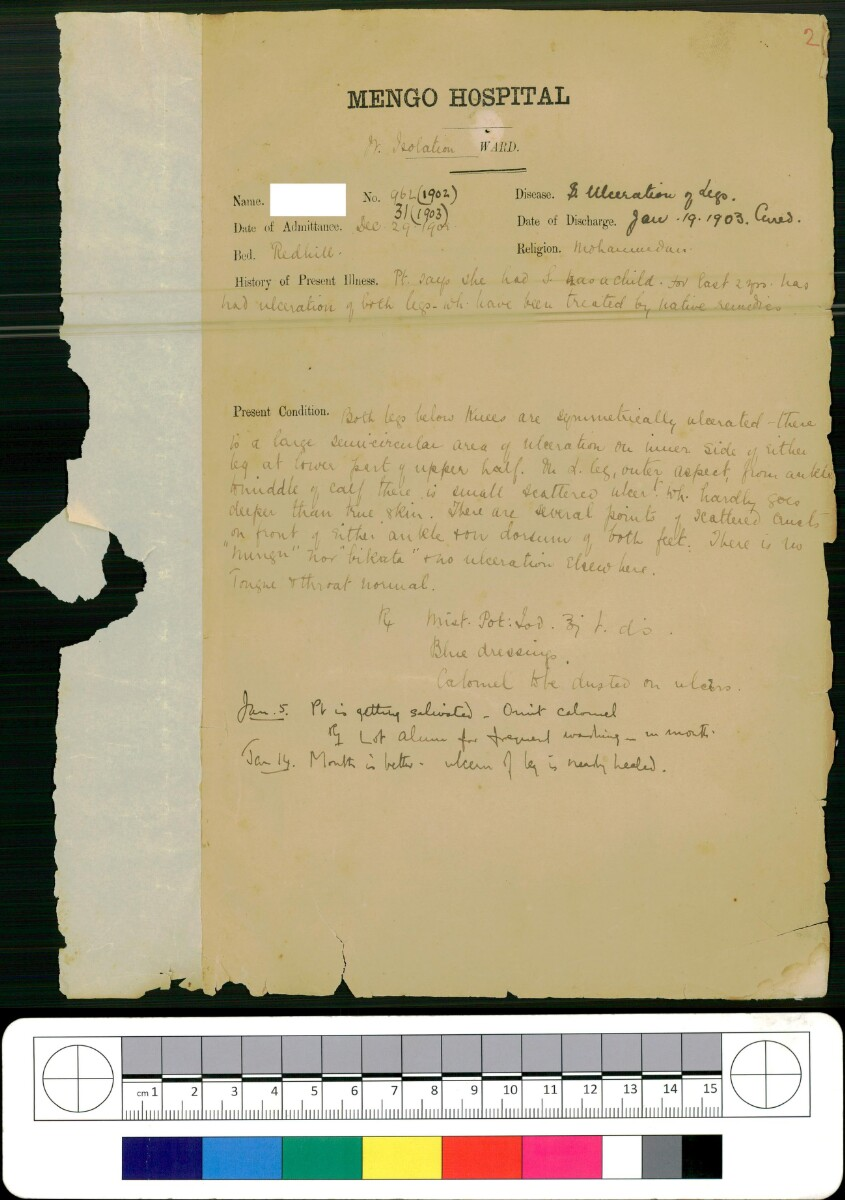

In [ ]:
# @title Inspect a random page from the downloaded images
import random
from PIL import Image
import matplotlib.pyplot as plt
import os

img_folder = "img"
img_files = [f for f in os.listdir(img_folder) if f.lower().endswith(('.png', '.jpg'))]
random_img_file = random.choice(img_files)
img_path = os.path.join(img_folder, random_img_file)
img = Image.open(img_path)
img

We're now going to create a folder named `fantastic_futures_img` in Drive. Feel free to change the name if you like.  The main goal is to create a folder of images that we can access in the next section.

In [ ]:
import shutil
import os

source_dir = '/content/img'
destination_dir = '/content/drive/MyDrive/fantastic_futures_img'

os.makedirs(destination_dir, exist_ok=True)

for item in os.listdir(source_dir):
    s = os.path.join(source_dir, item)
    d = os.path.join(destination_dir, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, symlinks=False, ignore=None)
    else:
        shutil.copy2(s, d)
print(f"Contents of {source_dir} copied to {destination_dir}")

Contents of /content/img copied to /content/drive/MyDrive/fantastic_futures_img
